In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [5]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

                    Feature  Coefficient
0               mean radius     1.027437
1              mean texture     0.221451
2            mean perimeter    -0.362135
3                 mean area     0.025467
4           mean smoothness    -0.156235
5          mean compactness    -0.237713
6            mean concavity    -0.532558
7       mean concave points    -0.283692
8             mean symmetry    -0.226682
9    mean fractal dimension    -0.036494
10             radius error    -0.097102
11            texture error     1.370567
12          perimeter error    -0.181409
13               area error    -0.087196
14         smoothness error    -0.022455
15        compactness error     0.047361
16          concavity error    -0.042948
17     concave points error    -0.032402
18           symmetry error    -0.034737
19  fractal dimension error     0.011605
20             worst radius     0.111653
21            worst texture    -0.508877
22          worst perimeter    -0.015554
23              

In [6]:
y_pred = model.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193

Confusion Matrix:
[[39  4]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



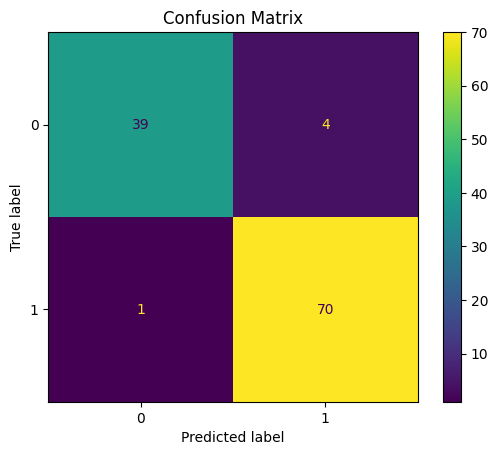

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()

In [9]:
probabilities = model.predict_proba(X_test)

print(probabilities[:10])

[[1.23478439e-01 8.76521561e-01]
 [9.99999971e-01 2.94052334e-08]
 [9.98388079e-01 1.61192105e-03]
 [1.26347550e-03 9.98736524e-01]
 [1.48669418e-04 9.99851331e-01]
 [1.00000000e+00 2.06075485e-10]
 [1.00000000e+00 5.81744739e-11]
 [9.80796515e-01 1.92034846e-02]
 [1.54681978e-02 9.84531802e-01]
 [5.73453943e-03 9.94265461e-01]]
